In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

C:\Users\teddy\AppData\Local\Temp\ipykernel_24008\2195291694.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['topic'] = df_clean['topic'].astype(str)


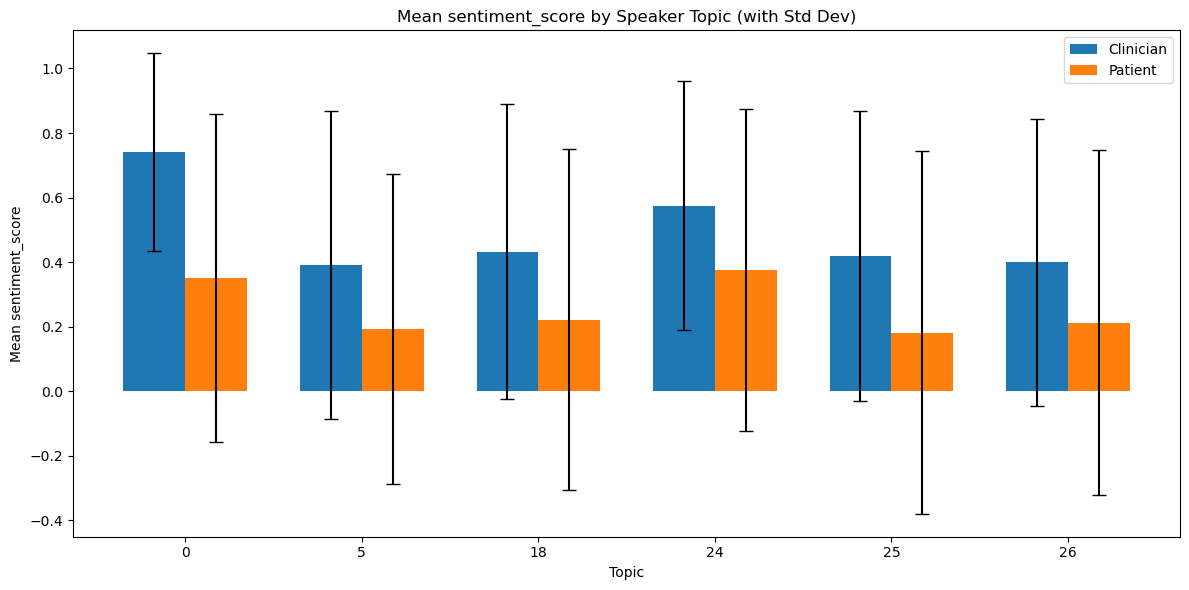

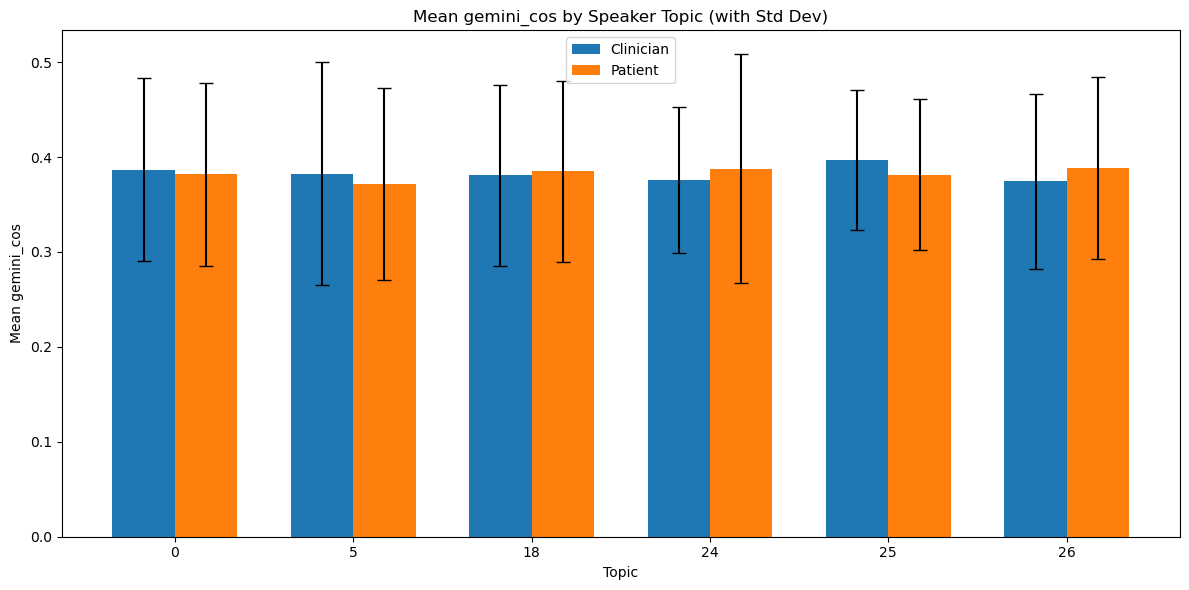

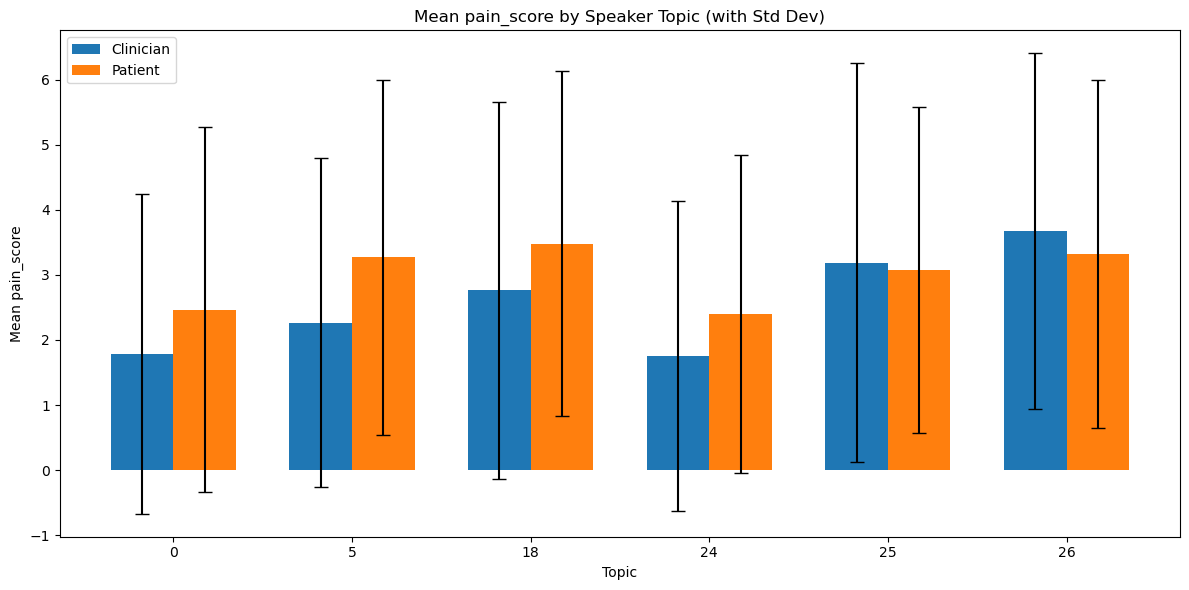

In [11]:
# Load the dataset
file_path = '30tp_cutoffline_0.950.csv'
df = pd.read_csv(file_path)

# Drop rows with missing topic, speaker, or sentiment_score
df_clean = df.dropna(subset=['topic', 'Speaker', 'sentiment_score'])

# Split multi-topic entries (like "1,2") into separate rows
df_clean['topic'] = df_clean['topic'].astype(str)
df_expanded = df_clean.assign(topic=df_clean['topic'].str.split(',')).explode('topic')
df_expanded['topic'] = df_expanded['topic'].astype(int)

def plot_topic_dist(score_col):
    # Group by topic and speaker, compute mean and std deviation
    summary = df_expanded.groupby(['topic', 'Speaker'])[score_col].agg(['mean', 'std']).reset_index()

    # Pivot to separate columns for Clinician and Patient
    summary_pivot = summary.pivot(index='topic', columns='Speaker', values=['mean', 'std'])
    summary_pivot.columns = [f'{stat}_{speaker}' for stat, speaker in summary_pivot.columns]
    summary_pivot.reset_index(inplace=True)

    filtered = summary_pivot.dropna(subset=['mean_CLINICIAN', 'mean_PATIENT'])
    # Extract standard deviation values for error bars
    clinician_means = filtered['mean_CLINICIAN']
    patient_means = filtered['mean_PATIENT']
    clinician_stds = filtered['std_CLINICIAN']
    patient_stds = filtered['std_PATIENT']

    # Plot with error bars (std deviation)
    plt.figure(figsize=(12, 6))
    index = range(len(filtered))
    bar_width = 0.35

    plt.bar([i - bar_width/2 for i in index], clinician_means, yerr=clinician_stds,
            width=bar_width, label='Clinician', capsize=5)
    plt.bar([i + bar_width/2 for i in index], patient_means, yerr=patient_stds,
            width=bar_width, label='Patient', capsize=5)

    # Labels and title
    plt.xlabel('Topic')
    plt.ylabel(f'Mean {score_col}')
    plt.title(f'Mean {score_col} by Speaker Topic (with Std Dev)')
    plt.xticks(index, filtered['topic'])
    plt.legend()
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_topic_dist('sentiment_score')
plot_topic_dist('gemini_cos')
plot_topic_dist('pain_score')